In [ ]:
import json
import random


films = []
with open('full_dump.jsonl', 'r', encoding='UTF-8') as f:
    for line in f:
        films.append(json.loads(line))

n = len(films)
print(n)

In [ ]:
from langdetect import detect
import json
import random

annotations = []
viewed = [0]
count = 0
movie_subset = 100000
with open("top_reviews.jsonl","w",encoding='UTF-8') as f:
    while count < movie_subset:
        r = random.randint(0,n-1)
        current_film = films[r]
        reviews_list = current_film.get("reviews", [])


        if not reviews_list:
            continue 
        try:
            if detect(current_film.get("reviews")[0].get("review_text")) != 'en':
                continue
        except:
            continue
        if current_film.get('rating') is None:
            continue
        if current_film.get("reviews")[0].get("review_text").strip().endswith("...") or current_film.get("reviews")[0].get("review_text").strip().endswith("…"):
            continue
        data = {
            "title" : current_film.get("title",),
            "year" : current_film.get("year"),
            "synopsis" : current_film.get("synopsis"),
            "reviews" : current_film.get("reviews")[0].get("review_text"),
            "rating" : current_film.get('rating')
        }
        f.write(json.dumps(data) + "\n")
        count +=1

In [5]:
import json

random_films = []
with open('top_reviews.jsonl', 'r', encoding='UTF-8') as f:
    for line in f:
        random_films.append(json.loads(line))


In [6]:
import sklearn
train_set, test_set = sklearn.model_selection.train_test_split(random_films, test_size=0.1)
train_texts = []
train_labels = []
test_texts = []
test_labels = []
for item in train_set:
    train_texts.append(item['reviews'])
    train_labels.append(round(float(item['rating'][:4])))
for item in test_set:
    test_texts.append(item['reviews'])
    test_labels.append(round(float(item['rating'][:4])))


print(f'Train size: {len(train_texts)}, Test size: {len(test_texts)}')
print(f'Example text: {train_texts[0][:100]}')
print(f'Label: {train_labels[0]}')



Train size: 90000, Test size: 10000
Example text: Scottish/British '80s gothic horror drama so full of that decade's usual suspects in dark pseudo-pre
Label: 3


# Logistic Regression Classifier

In [7]:
# --- Bag-of-Words Model ---
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
# YOUR CODE HERE: vectorize texts using CountVectorizer
vectorizer = CountVectorizer()  # TODO

X_train = vectorizer.fit_transform(train_texts)  # TODO
X_test  = vectorizer.transform(test_texts)  # TODO


clf_bow = LogisticRegression(max_iter=10000) # TODO
clf_bow.fit(X_train, train_labels)


y_pred_bow = clf_bow.predict(X_test)  # TODO

acc_bow = accuracy_score(test_labels, y_pred_bow)
f1_bow  = f1_score(test_labels, y_pred_bow, average='macro')
precision = precision_score(test_labels,y_pred_bow, average='macro')
recall = recall_score(test_labels,y_pred_bow, average='macro')
print(f'Accuracy: {acc_bow:.4f}')
print(f'Macro F1: {f1_bow:.4f}')
print(f'Precision:{precision:.4f}')
print(f'Recall:{recall:.4f}')


Accuracy: 0.8199
Macro F1: 0.6472
Precision:0.8902
Recall:0.5518


In [8]:
import pickle
pickle.dump(clf_bow, open('logistic_regression_classifier','wb'))

In [9]:
model = pickle.load(open('logistic_regression_classifier','rb'))


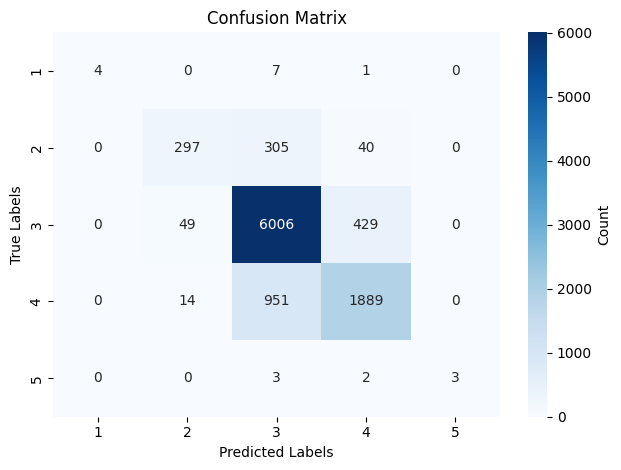

In [21]:
# confusion matrix with labels true and predicted
from sklearn.metrics import confusion_matrix
from seaborn import heatmap
import matplotlib.pyplot as plt

labels = [1, 2, 3, 4, 5]
cm = confusion_matrix(test_labels, y_pred_bow, labels=labels)

ax = heatmap(cm, annot=True, fmt='d', cmap="Blues",
             xticklabels=labels, yticklabels=labels,
             cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()



# Majority Baseline

Accuracy: 0.6484
Macro F1: 0.1573
Precision: 0.1297
Recall: 0.2000


/Users/asad/Documents/repos/4NL3_Final_Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


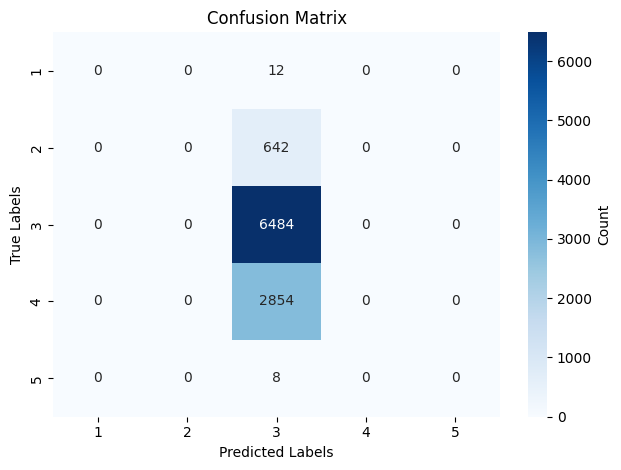

In [22]:
# Model baseline, just predict every review to be 3
y_pred_baseline = [3] * len(test_texts)

# Calculate metrics
acc_baseline = accuracy_score(test_labels, y_pred_baseline)
f1_baseline = f1_score(test_labels, y_pred_baseline, average='macro')
precision_baseline = precision_score(test_labels, y_pred_baseline, average='macro')
recall_baseline = recall_score(test_labels, y_pred_baseline, average='macro')

print(f'Accuracy: {acc_baseline:.4f}')
print(f'Macro F1: {f1_baseline:.4f}')
print(f'Precision: {precision_baseline:.4f}')
print(f'Recall: {recall_baseline:.4f}')

# confusion matrix
cm_baseline = confusion_matrix(test_labels, y_pred_baseline, labels=labels)

ax = heatmap(cm_baseline, annot=True, fmt='d', cmap="Blues",
             xticklabels=labels, yticklabels=labels,
             cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Random Baseline

Accuracy: 0.2023
Macro F1: 0.1299
Precision: 0.2004
Recall: 0.2056


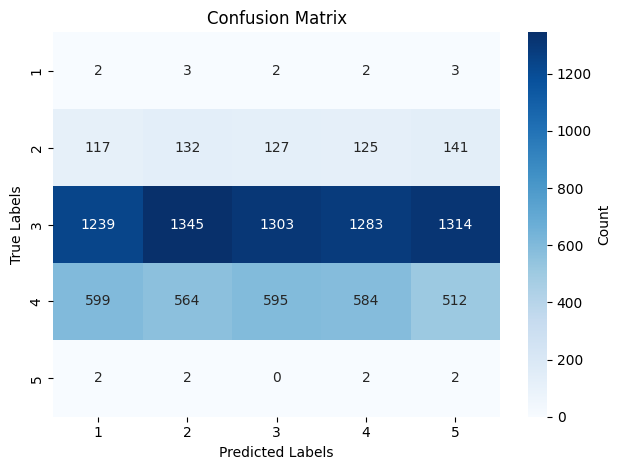

In [23]:
# Generate random predictions
y_pred_random = [random.randint(1, 5) for _ in range(len(test_texts))]

# Calculate metrics
acc_random = accuracy_score(test_labels, y_pred_random)
f1_random = f1_score(test_labels, y_pred_random, average='macro')
precision_random = precision_score(test_labels, y_pred_random, average='macro')
recall_random = recall_score(test_labels, y_pred_random, average='macro')

print(f'Accuracy: {acc_random:.4f}')
print(f'Macro F1: {f1_random:.4f}')
print(f'Precision: {precision_random:.4f}')
print(f'Recall: {recall_random:.4f}')

# confusion matrix
cm_random = confusion_matrix(test_labels, y_pred_random, labels=labels)

ax = heatmap(cm_random, annot=True, fmt='d', cmap="Blues",
             xticklabels=labels, yticklabels=labels,
             cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()


In [25]:
import numpy as np

# Calculate MSE of all 3 baselines
mse_baseline = np.mean((np.array(test_labels) - np.array(y_pred_bow)) ** 2)
mse_majority = np.mean((np.array(test_labels) - np.array(y_pred_baseline)) ** 2)
mse_random = np.mean((np.array(test_labels) - np.array(y_pred_random)) ** 2)


# Calculate MAE of all 3 baselines
mae_baseline = np.mean(np.abs(np.array(test_labels) - np.array(y_pred_bow)))
mae_majority = np.mean(np.abs(np.array(test_labels) - np.array(y_pred_baseline)))
mae_random = np.mean(np.abs(np.array(test_labels) - np.array(y_pred_random)))


print(f'MSE Baseline: {mse_baseline:.4f}')
print(f'MSE Random: {mse_random:.4f}')
print(f'MSE Majority: {mse_majority:.4f}')

print(f'MAE Baseline: {mae_baseline:.4f}')
print(f'MAE Random: {mae_random:.4f}')
print(f'MAE Majority: {mae_majority:.4f}')


MSE Baseline: 0.2001
MSE Random: 2.3736
MSE Majority: 0.3576
MAE Baseline: 0.1867
MAE Random: 1.2724
MAE Majority: 0.3536
